# **Analysis 01 - Comparison of Means**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

customer_data = pd.read_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    parse_dates=["LastPurchase"]
)

print(customer_data.shape)
customer_data.head()

(4266, 30)


,CustomerID,LastPurchase,Frequency,MonetaryValue,TotalQuantity,ProductDiversity,RecencyDays,FuturePurchaseCount,FutureRevenue,RepeatPurchase,...,ActivePurchaseDays,CustomerTenureDays,ReturnInvoiceCount,ReturnLineCount,HistoricalReturnValue,ReturnInvoiceRate,AverageDaysBetweenOrders,StdDaysBetweenOrders,PrimaryCountry,IsUK
0,12346,2010-06-28 13:53:00,11,372.86,70,26,155,1.0,77183.60,1,...,7,351,4.0,12.0,424.60,0.266667,19.622153,36.622360,United Kingdom,1
1,12347,2010-10-31 14:20:00,1,611.53,509,40,30,7.0,4310.00,1,...,1,30,0.0,0.0,0.00,0.000000,0.000000,0.000000,Iceland,0
2,12348,2010-09-27 14:59:00,1,222.16,373,20,64,4.0,1797.24,1,...,1,64,0.0,0.0,0.00,0.000000,0.000000,0.000000,Finland,0
3,12349,2010-10-28 08:23:00,3,2671.14,993,90,33,1.0,1757.55,1,...,3,215,1.0,5.0,24.15,0.250000,90.896875,101.876901,Italy,0
4,12351,2010-11-29 15:23:00,1,300.93,261,21,1,0.0,0.00,0,...,1,1,0.0,0.0,0.00,0.000000,0.000000,0.000000,Unspecified,0


In [2]:
import numpy as np
import pandas as pd
from scipy import stats

# Recreate the variable if it is not already available
customer_data["LogMonetaryValue"] = np.log1p(
    customer_data["MonetaryValue"]
)

returned = customer_data.loc[
    customer_data["RepeatPurchase"] == 1,
    "LogMonetaryValue"
].dropna()

not_returned = customer_data.loc[
    customer_data["RepeatPurchase"] == 0,
    "LogMonetaryValue"
].dropna()

print("Returning customers:", len(returned))
print("Non-returning customers:", len(not_returned))

Returning customers: 2726
Non-returning customers: 1540


In [3]:
group_summary = (
    customer_data
    .groupby("RepeatPurchase")
    .agg(
        Customers=("CustomerID", "count"),
        Mean_Log_Monetary=("LogMonetaryValue", "mean"),
        SD_Log_Monetary=("LogMonetaryValue", "std"),
        Median_Raw_Monetary=("MonetaryValue", "median"),
        Mean_Raw_Monetary=("MonetaryValue", "mean")
    )
    .round(3)
)

group_summary.index = [
    "Did not return",
    "Returned"
]

group_summary

,Customers,Mean_Log_Monetary,SD_Log_Monetary,Median_Raw_Monetary,Mean_Raw_Monetary
Did not return,1540,5.905,1.077,346.530,716.503
Returned,2726,6.982,1.211,1061.765,2708.790


In [4]:
welch_result = stats.ttest_ind(
    returned,
    not_returned,
    equal_var=False
)

t_statistic = welch_result.statistic
p_value = welch_result.pvalue

print(f"Welch t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6g}")

Welch t-statistic: 29.9491
p-value: 1.02307e-175


In [5]:
n_returned = len(returned)
n_not_returned = len(not_returned)

mean_returned = returned.mean()
mean_not_returned = not_returned.mean()

var_returned = returned.var(ddof=1)
var_not_returned = not_returned.var(ddof=1)

mean_difference = mean_returned - mean_not_returned

standard_error = np.sqrt(
    var_returned / n_returned
    +
    var_not_returned / n_not_returned
)

welch_df = (
    (
        var_returned / n_returned
        + var_not_returned / n_not_returned
    ) ** 2
    /
    (
        (var_returned / n_returned) ** 2
        / (n_returned - 1)
        +
        (var_not_returned / n_not_returned) ** 2
        / (n_not_returned - 1)
    )
)

critical_t = stats.t.ppf(
    0.975,
    df=welch_df
)

ci_lower = mean_difference - critical_t * standard_error
ci_upper = mean_difference + critical_t * standard_error

print(f"Mean log difference: {mean_difference:.4f}")
print(f"Welch degrees of freedom: {welch_df:.2f}")
print(
    f"95% confidence interval: "
    f"[{ci_lower:.4f}, {ci_upper:.4f}]"
)

Mean log difference: 1.0761
Welch degrees of freedom: 3513.07
95% confidence interval: [1.0057, 1.1466]


In [6]:
pooled_sd = np.sqrt(
    (
        (n_returned - 1) * var_returned
        +
        (n_not_returned - 1) * var_not_returned
    )
    /
    (n_returned + n_not_returned - 2)
)

cohens_d = mean_difference / pooled_sd

correction_factor = (
    1
    -
    3
    /
    (
        4 * (n_returned + n_not_returned)
        - 9
    )
)

hedges_g = correction_factor * cohens_d

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Hedges' g: {hedges_g:.4f}")

Cohen's d: 0.9240
Hedges' g: 0.9239


In [7]:
geometric_mean_ratio = np.exp(
    mean_difference
)

approximate_percentage_difference = (
    geometric_mean_ratio - 1
) * 100

print(
    "Ratio of geometric means:",
    round(geometric_mean_ratio, 3)
)

print(
    "Approximate percentage difference:",
    round(approximate_percentage_difference, 1),
    "%"
)

Ratio of geometric means: 2.933
Approximate percentage difference: 193.3 %


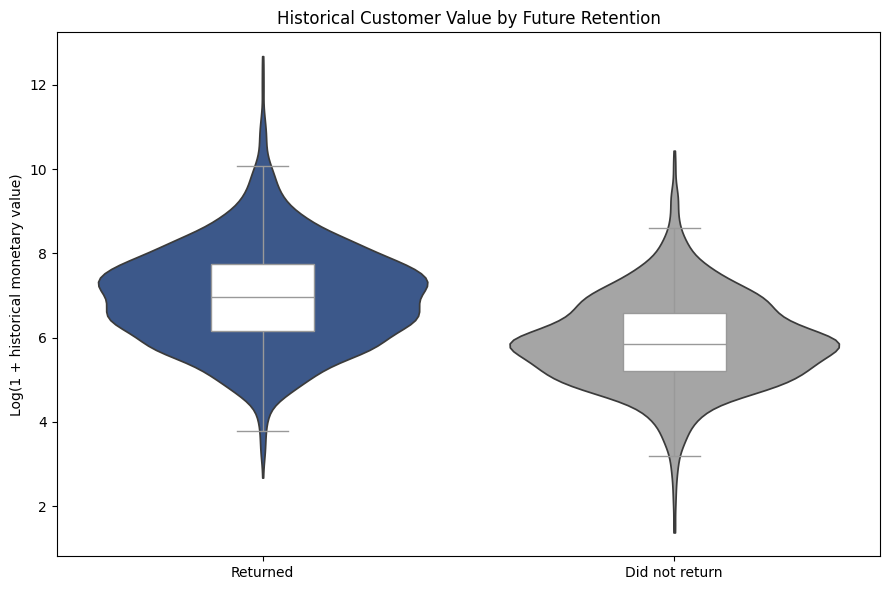

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

plot_data = customer_data.copy()

plot_data["CustomerOutcome"] = (
    plot_data["RepeatPurchase"]
    .map({
        0: "Did not return",
        1: "Returned"
    })
)

plt.figure(figsize=(9, 6))

sns.violinplot(
    data=plot_data,
    x="CustomerOutcome",
    y="LogMonetaryValue",
    hue="CustomerOutcome",
    palette={
        "Did not return": "#A5A5A5",
        "Returned": "#2F5597"
    },
    inner=None,
    legend=False,
    cut=0
)

sns.boxplot(
    data=plot_data,
    x="CustomerOutcome",
    y="LogMonetaryValue",
    width=0.25,
    color="white",
    showfliers=False
)

plt.title(
    "Historical Customer Value by Future Retention"
)
plt.xlabel("")
plt.ylabel("Log(1 + historical monetary value)")
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/06_monetary_value_welch_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2059/424083210.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


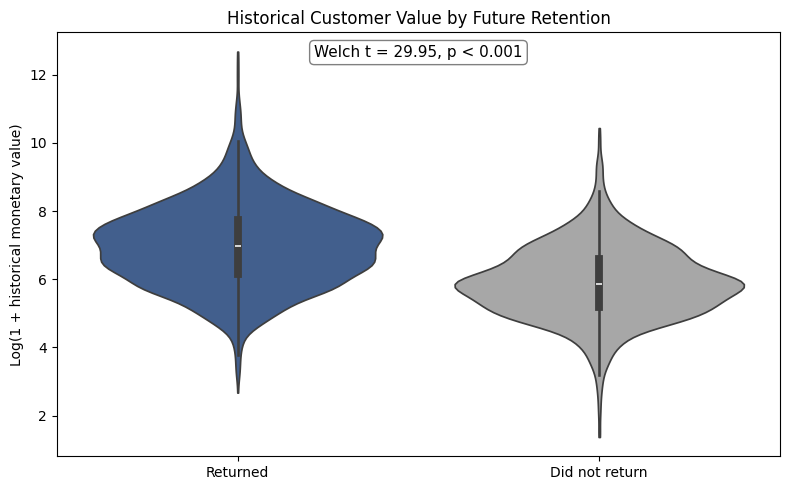

Returned customers: n = 2726
Did not return: n = 1540
Welch t-statistic = 29.9491
P-value = 1.02307e-175


In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Use your customer-level dataframe
plot_data = customer_data.copy()

# Create log monetary value only if it does not already exist
if "LogMonetaryValue" not in plot_data.columns:
    plot_data["LogMonetaryValue"] = np.log1p(
        plot_data["MonetaryValue"]
    )

# Create readable group labels
plot_data["RetentionStatus"] = plot_data["RepeatPurchase"].map({
    1: "Returned",
    0: "Did not return"
})

# Separate the two independent groups
returned = plot_data.loc[
    plot_data["RepeatPurchase"] == 1,
    "LogMonetaryValue"
].dropna()

not_returned = plot_data.loc[
    plot_data["RepeatPurchase"] == 0,
    "LogMonetaryValue"
].dropna()

# Welch independent-samples t-test
t_stat, p_value = ttest_ind(
    returned,
    not_returned,
    equal_var=False
)

# Plot
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=plot_data,
    x="RetentionStatus",
    y="LogMonetaryValue",
    order=["Returned", "Did not return"],
    inner="box",
    palette=["#355C9A", "#A7A7A7"],
    cut=0
)

plt.title("Historical Customer Value by Future Retention")
plt.xlabel("")
plt.ylabel("Log(1 + historical monetary value)")

p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"

plt.text(
    0.5,
    0.97,
    f"Welch t = {t_stat:.2f}, {p_text}",
    transform=plt.gca().transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="grey"
    )
)

plt.tight_layout()
plt.show()

print(f"Returned customers: n = {len(returned)}")
print(f"Did not return: n = {len(not_returned)}")
print(f"Welch t-statistic = {t_stat:.4f}")
print(f"P-value = {p_value:.6g}")

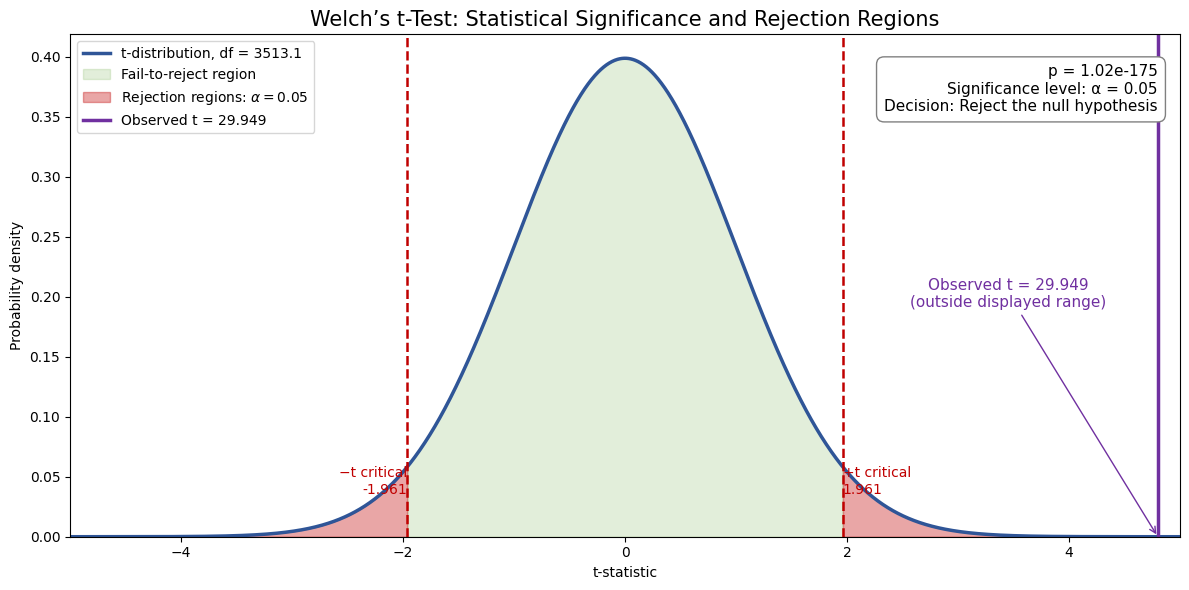

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

alpha = 0.05

# Keep the plot readable even when the observed t-value is extremely large
x_limit = 5

x = np.linspace(
    -x_limit,
    x_limit,
    2000
)

density = stats.t.pdf(
    x,
    df=welch_df
)

fig, ax = plt.subplots(figsize=(12, 6))

# Main t-distribution
ax.plot(
    x,
    density,
    color="#2F5597",
    linewidth=2.5,
    label=f"t-distribution, df = {welch_df:.1f}"
)

# Central non-rejection region
central_mask = (
    (x >= -critical_t)
    & (x <= critical_t)
)

ax.fill_between(
    x[central_mask],
    density[central_mask],
    color="#70AD47",
    alpha=0.20,
    label="Fail-to-reject region"
)

# Left rejection region
left_rejection = x <= -critical_t

ax.fill_between(
    x[left_rejection],
    density[left_rejection],
    color="#C00000",
    alpha=0.35
)

# Right rejection region
right_rejection = x >= critical_t

ax.fill_between(
    x[right_rejection],
    density[right_rejection],
    color="#C00000",
    alpha=0.35,
    label=r"Rejection regions: $\alpha=0.05$"
)

# Critical-value lines
ax.axvline(
    -critical_t,
    color="#C00000",
    linestyle="--",
    linewidth=1.8
)

ax.axvline(
    critical_t,
    color="#C00000",
    linestyle="--",
    linewidth=1.8
)

# Display the observed t-statistic
# If it is outside the visible range, position the line near the edge.
observed_plot_position = np.clip(
    t_statistic,
    -x_limit * 0.96,
    x_limit * 0.96
)

ax.axvline(
    observed_plot_position,
    color="#7030A0",
    linewidth=2.5,
    label=f"Observed t = {t_statistic:.3f}"
)

# Critical-value labels
max_density = density.max()

ax.text(
    -critical_t,
    max_density * 0.09,
    f"−t critical\n{(-critical_t):.3f}",
    color="#C00000",
    ha="right",
    fontsize=10
)

ax.text(
    critical_t,
    max_density * 0.09,
    f"+t critical\n{critical_t:.3f}",
    color="#C00000",
    ha="left",
    fontsize=10
)

# Indicate whether observed statistic is outside the displayed range
if abs(t_statistic) > x_limit:
    observed_label = (
        f"Observed t = {t_statistic:.3f}\n"
        "(outside displayed range)"
    )
else:
    observed_label = f"Observed t = {t_statistic:.3f}"

ax.annotate(
    observed_label,
    xy=(
        observed_plot_position,
        stats.t.pdf(
            observed_plot_position,
            df=welch_df
        )
    ),
    xytext=(
        observed_plot_position * 0.72,
        max_density * 0.48
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#7030A0"
    },
    color="#7030A0",
    fontsize=11,
    ha="center"
)

# Format very small p-values appropriately
if p_value < 0.001:
    p_text = f"p = {p_value:.2e}"
else:
    p_text = f"p = {p_value:.4f}"

decision = (
    "Reject the null hypothesis"
    if p_value < alpha
    else "Do not reject the null hypothesis"
)

result_text = (
    f"{p_text}\n"
    f"Significance level: α = {alpha}\n"
    f"Decision: {decision}"
)

ax.text(
    0.98,
    0.94,
    result_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "#808080"
    }
)

ax.set_title(
    "Welch’s t-Test: Statistical Significance and Rejection Regions",
    fontsize=15
)

ax.set_xlabel("t-statistic")
ax.set_ylabel("Probability density")

ax.legend(
    loc="upper left",
    frameon=True
)

ax.set_xlim(-x_limit, x_limit)
ax.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/07_welch_t_significance_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Analysis 02 - Comparison of Propotions**

In [11]:
country_table = pd.crosstab(
    customer_data["IsUK"],
    customer_data["RepeatPurchase"]
)

country_table.index = [
    "Non-UK",
    "UK"
]

country_table.columns = [
    "Did not return",
    "Returned"
]

country_table

,Did not return,Returned
Non-UK,110,227
UK,1430,2499


In [12]:
country_summary = (
    customer_data
    .groupby("IsUK")
    .agg(
        Customers=("CustomerID", "count"),
        ReturnedCustomers=("RepeatPurchase", "sum"),
        RepeatRate=("RepeatPurchase", "mean")
    )
)

country_summary.index = [
    "Non-UK",
    "UK"
]

country_summary["RepeatRatePercentage"] = (
    country_summary["RepeatRate"] * 100
)

country_summary.round(3)

,Customers,ReturnedCustomers,RepeatRate,RepeatRatePercentage
Non-UK,337,227,0.674,67.359
UK,3929,2499,0.636,63.604


In [13]:
from statsmodels.stats.proportion import proportions_ztest

uk_customers = customer_data[
    customer_data["IsUK"] == 1
]

non_uk_customers = customer_data[
    customer_data["IsUK"] == 0
]

uk_returned = uk_customers["RepeatPurchase"].sum()
uk_total = len(uk_customers)

non_uk_returned = (
    non_uk_customers["RepeatPurchase"].sum()
)
non_uk_total = len(non_uk_customers)

success_counts = np.array([
    uk_returned,
    non_uk_returned
])

sample_sizes = np.array([
    uk_total,
    non_uk_total
])

z_statistic, p_value_proportion = proportions_ztest(
    count=success_counts,
    nobs=sample_sizes,
    alternative="two-sided"
)

print(f"UK customers: {uk_total}")
print(f"UK returning customers: {uk_returned}")
print(
    f"UK repeat rate: "
    f"{uk_returned / uk_total:.2%}"
)

print(f"\nNon-UK customers: {non_uk_total}")
print(
    f"Non-UK returning customers: "
    f"{non_uk_returned}"
)
print(
    f"Non-UK repeat rate: "
    f"{non_uk_returned / non_uk_total:.2%}"
)

print(f"\nz-statistic: {z_statistic:.4f}")
print(f"p-value: {p_value_proportion:.6g}")

UK customers: 3929
UK returning customers: 2499
UK repeat rate: 63.60%

Non-UK customers: 337
Non-UK returning customers: 227
Non-UK repeat rate: 67.36%

z-statistic: -1.3774
p-value: 0.168386


In [14]:
p_uk = uk_returned / uk_total
p_non_uk = non_uk_returned / non_uk_total

proportion_difference = p_uk - p_non_uk

difference_se = np.sqrt(
    p_uk * (1 - p_uk) / uk_total
    +
    p_non_uk * (1 - p_non_uk) / non_uk_total
)

z_critical = 1.96

difference_ci_lower = (
    proportion_difference
    - z_critical * difference_se
)

difference_ci_upper = (
    proportion_difference
    + z_critical * difference_se
)

print(
    "Repeat-rate difference:",
    f"{proportion_difference:.2%}"
)

print(
    "95% confidence interval:",
    f"[{difference_ci_lower:.2%}, "
    f"{difference_ci_upper:.2%}]"
)

Repeat-rate difference: -3.76%
95% confidence interval: [-8.98%, 1.47%]


In [15]:
relative_risk = p_uk / p_non_uk

rr_standard_error = np.sqrt(
    (1 / uk_returned)
    - (1 / uk_total)
    + (1 / non_uk_returned)
    - (1 / non_uk_total)
)

rr_ci_lower = np.exp(
    np.log(relative_risk)
    - z_critical * rr_standard_error
)

rr_ci_upper = np.exp(
    np.log(relative_risk)
    + z_critical * rr_standard_error
)

print(f"Relative risk: {relative_risk:.3f}")

print(
    "95% relative-risk confidence interval:",
    f"[{rr_ci_lower:.3f}, {rr_ci_upper:.3f}]"
)

Relative risk: 0.944
95% relative-risk confidence interval: [0.873, 1.021]


In [16]:
from scipy.stats import chi2_contingency

chi2, chi2_p, dof, expected_counts = (
    chi2_contingency(country_table)
)

print("Expected cell counts:")
print(expected_counts)

print(
    "Minimum expected count:",
    expected_counts.min()
)

Expected cell counts:
[[ 121.65494609  215.34505391]
 [1418.34505391 2510.65494609]]
Minimum expected count: 121.65494608532583


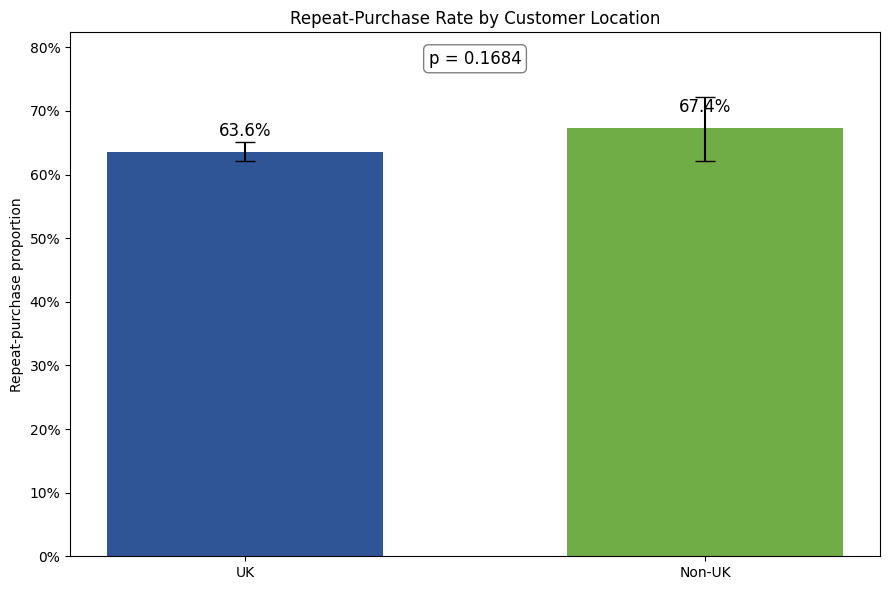

In [18]:
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt

uk_ci = proportion_confint(
    uk_returned,
    uk_total,
    alpha=0.05,
    method="wilson"
)

non_uk_ci = proportion_confint(
    non_uk_returned,
    non_uk_total,
    alpha=0.05,
    method="wilson"
)

groups = ["UK", "Non-UK"]
proportions = [p_uk, p_non_uk]

lower_errors = [
    p_uk - uk_ci[0],
    p_non_uk - non_uk_ci[0]
]

upper_errors = [
    uk_ci[1] - p_uk,
    non_uk_ci[1] - p_non_uk
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    groups,
    proportions,
    color=["#2F5597", "#70AD47"],
    width=0.6
)

ax.errorbar(
    groups,
    proportions,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    color="black",
    capsize=7,
    linewidth=1.5
)

for bar, proportion in zip(bars, proportions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{proportion:.1%}",
        ha="center",
        fontsize=12
    )

if p_value_proportion < 0.001:
    p_label = f"p = {p_value_proportion:.2e}"
else:
    p_label = f"p = {p_value_proportion:.4f}"

ax.text(
    0.5,
    0.94,
    p_label,
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "edgecolor": "#808080"
    }
)

ax.set_title(
    "Repeat-Purchase Rate by Customer Location"
)
ax.set_ylabel("Repeat-purchase proportion")
ax.set_xlabel("")
ax.set_ylim(
    0,
    min(1, max(proportions) + 0.15)
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.0%}"
    )
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/08_country_repeat_proportion_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Analysis 03 - Comparison of Variances**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import levene

repeat_log_spending = customer_data.loc[
    customer_data["RepeatPurchase"] == 1,
    "LogMonetaryValue"
].dropna()

nonrepeat_log_spending = customer_data.loc[
    customer_data["RepeatPurchase"] == 0,
    "LogMonetaryValue"
].dropna()

levene_stat, levene_p = levene(
    repeat_log_spending,
    nonrepeat_log_spending,
    center="median"
)

print(f"Levene statistic: {levene_stat:.4f}")
print(f"P-value: {levene_p:.6f}")

if levene_p < 0.05:
    print("Reject H0: the group variances are significantly different.")
else:
    print("Fail to reject H0: there is insufficient evidence that the variances differ.")

Levene statistic: 32.2740
P-value: 0.000000
Reject H0: the group variances are significantly different.


In [21]:
variance_results = pd.DataFrame({
    "Group": ["Did not return", "Returned"],
    "Sample size": [
        len(nonrepeat_log_spending),
        len(repeat_log_spending)
    ],
    "Mean log monetary value": [
        nonrepeat_log_spending.mean(),
        repeat_log_spending.mean()
    ],
    "Variance": [
        nonrepeat_log_spending.var(ddof=1),
        repeat_log_spending.var(ddof=1)
    ],
    "Standard deviation": [
        nonrepeat_log_spending.std(ddof=1),
        repeat_log_spending.std(ddof=1)
    ]
})

variance_results.round(3)

,Group,Sample size,Mean log monetary value,Variance,Standard deviation
0,Did not return,1540,5.905,1.159,1.077
1,Returned,2726,6.982,1.468,1.211


/tmp/ipykernel_2059/3893077511.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


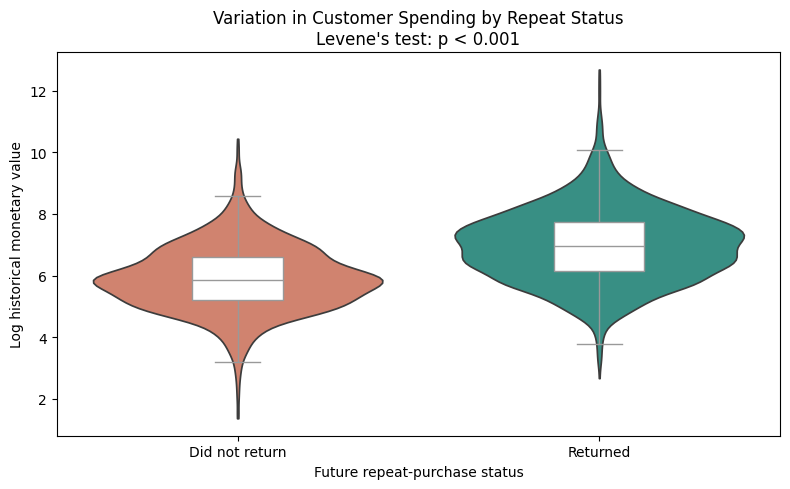

Levene statistic: 32.2740
P-value: 1.42808e-08


In [23]:
from scipy.stats import levene
import seaborn as sns
import matplotlib.pyplot as plt

not_returned = customer_data.loc[
    customer_data["RepeatPurchase"] == 0,
    "LogMonetaryValue"
].dropna()

returned = customer_data.loc[
    customer_data["RepeatPurchase"] == 1,
    "LogMonetaryValue"
].dropna()

# Median-centred Levene test, also called the Brown–Forsythe test
levene_stat, levene_p = levene(
    not_returned,
    returned,
    center="median"
)

p_text = (
    "p < 0.001"
    if levene_p < 0.001
    else f"p = {levene_p:.4f}"
)

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=customer_data,
    x="RepeatPurchase",
    y="LogMonetaryValue",
    order=[0, 1],
    inner=None,
    palette=["#E07A5F", "#2A9D8F"],
    cut=0
)

sns.boxplot(
    data=customer_data,
    x="RepeatPurchase",
    y="LogMonetaryValue",
    order=[0, 1],
    width=0.25,
    showfliers=False,
    color="white"
)

plt.xticks([0, 1], ["Did not return", "Returned"])
plt.xlabel("Future repeat-purchase status")
plt.ylabel("Log historical monetary value")

plt.title(
    "Variation in Customer Spending by Repeat Status\n"
    f"Levene's test: {p_text}"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/levene_variance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Levene statistic: {levene_stat:.4f}")
print(f"P-value: {levene_p:.6g}")

In [ ]:
customer_data["FrequencyGroup"] = pd.cut(
    customer_data["Frequency"],
    bins=[0, 1, 3, 6, np.inf],
    labels=[
        "One-time",
        "Low (2–3)",
        "Medium (4–6)",
        "High (7+)"
    ]
)

customer_data["FrequencyGroup"].value_counts().sort_index()

,count
FrequencyGroup,
One-time,1431
Low (2–3),1323
Medium (4–6),807
High (7+),705


In [ ]:
customer_data["LogFutureRevenue"] = np.log1p(
    customer_data["FutureRevenue"]
)

In [ ]:
frequency_summary = (
    customer_data
    .groupby("FrequencyGroup", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        MeanFutureRevenue=("FutureRevenue", "mean"),
        MedianFutureRevenue=("FutureRevenue", "median"),
        MeanLogFutureRevenue=("LogFutureRevenue", "mean"),
        RepeatRate=("RepeatPurchase", "mean")
    )
)

frequency_summary["RepeatRate"] *= 100

frequency_summary.round(2)

,Customers,MeanFutureRevenue,MedianFutureRevenue,MeanLogFutureRevenue,RepeatRate
FrequencyGroup,,,,,
One-time,1431,304.97,0.00,2.37,38.78
Low (2–3),1323,679.27,263.33,4.10,64.63
Medium (4–6),807,1604.51,781.78,5.64,81.78
High (7+),705,6370.83,2603.43,7.38,93.05


In [ ]:
group_order = [
    "One-time",
    "Low (2–3)",
    "Medium (4–6)",
    "High (7+)"
]

revenue_groups = [
    customer_data.loc[
        customer_data["FrequencyGroup"] == group,
        "LogFutureRevenue"
    ].dropna()
    for group in group_order
]

revenue_levene_stat, revenue_levene_p = levene(
    *revenue_groups,
    center="median"
)

print(f"Levene statistic: {revenue_levene_stat:.4f}")
print(f"P-value: {revenue_levene_p:.6f}")

Levene statistic: 42.2690
P-value: 0.000000


In [ ]:
from statsmodels.stats.oneway import anova_oneway

welch_anova = anova_oneway(
    revenue_groups,
    use_var="unequal",
    welch_correction=True
)

print(welch_anova)

AnovaResult(statistic=np.float64(633.9846554933358), pvalue=np.float64(7.289393098087098e-294), df=(3.0, np.float64(2113.209370581478)), df_num=3.0, df_denom=np.float64(2113.209370581478), nobs_total=np.float64(4266.0), n_groups=4, means=array([2.37203863, 4.09982329, 5.64434957, 7.37991156]), nobs=array([1431., 1323.,  807.,  705.]), vars_=array([9.2690002 , 9.95078606, 8.05855742, 5.4485409 ]), use_var='unequal', welch_correction=True, df2=None, df_num2=None, pvalue2=None)


Welch’s one-way ANOVA found a statistically significant difference in mean log future revenue between the four historical purchase-frequency groups:

$$ F_W(3,\ 2113.21)=633.98,\quad p<0.001 $$

Therefore, the null hypothesis that all four population means are equal was rejected. Historical purchase frequency is significantly associated with customers’ future revenue.

Mean log future revenue increased consistently across the frequency groups:

One-time customers: \(M=2.37\)
Low-frequency customers: \(M=4.10\)
Medium-frequency customers: \(M=5.64\)
High-frequency customers: \(M=7.38\)

Customers who purchased more frequently during the historical period consequently generated substantially greater revenue during the future period.

In [ ]:
welch_f = welch_anova.statistic
welch_p = welch_anova.pvalue
welch_df_num = welch_anova.df_num
welch_df_denom = welch_anova.df_denom

print(f"Welch F-statistic: {welch_f:.4f}")
print(f"Numerator degrees of freedom: {welch_df_num:.2f}")
print(f"Denominator degrees of freedom: {welch_df_denom:.2f}")
print(f"P-value: {welch_p:.6f}")

if welch_p < 0.05:
    print(
        "Reject H0: mean log future revenue differs "
        "between at least two frequency groups."
    )
else:
    print(
        "Fail to reject H0: there is insufficient evidence "
        "of a difference between the group means."
    )

Welch F-statistic: 633.9847
Numerator degrees of freedom: 3.00
Denominator degrees of freedom: 2113.21
P-value: 0.000000
Reject H0: mean log future revenue differs between at least two frequency groups.


In [ ]:
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

pairwise_results = []

for group_1, group_2 in combinations(group_order, 2):

    values_1 = customer_data.loc[
        customer_data["FrequencyGroup"] == group_1,
        "LogFutureRevenue"
    ].dropna()

    values_2 = customer_data.loc[
        customer_data["FrequencyGroup"] == group_2,
        "LogFutureRevenue"
    ].dropna()

    statistic, p_value = ttest_ind(
        values_1,
        values_2,
        equal_var=False
    )

    pairwise_results.append({
        "Group 1": group_1,
        "Group 2": group_2,
        "Mean 1": values_1.mean(),
        "Mean 2": values_2.mean(),
        "Mean difference": values_1.mean() - values_2.mean(),
        "t-statistic": statistic,
        "Raw p-value": p_value
    })

pairwise_results = pd.DataFrame(pairwise_results)

pairwise_results["Adjusted p-value"] = multipletests(
    pairwise_results["Raw p-value"],
    method="holm"
)[1]

pairwise_results["Significant"] = (
    pairwise_results["Adjusted p-value"] < 0.05
)

pairwise_results.round(4)

,Group 1,Group 2,Mean 1,Mean 2,Mean difference,t-statistic,Raw p-value,Adjusted p-value,Significant
0,One-time,Low (2–3),2.3720,4.0998,-1.7278,-14.6031,0.0,0.0,True
1,One-time,Medium (4–6),2.3720,5.6443,-3.2723,-25.5034,0.0,0.0,True
2,One-time,High (7+),2.3720,7.3799,-5.0079,-42.0167,0.0,0.0,True
3,Low (2–3),Medium (4–6),4.0998,5.6443,-1.5445,-11.6731,0.0,0.0,True
4,Low (2–3),High (7+),4.0998,7.3799,-3.2801,-26.5615,0.0,0.0,True
5,Medium (4–6),High (7+),5.6443,7.3799,-1.7356,-13.0400,0.0,0.0,True


/tmp/ipykernel_1959/2601167749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


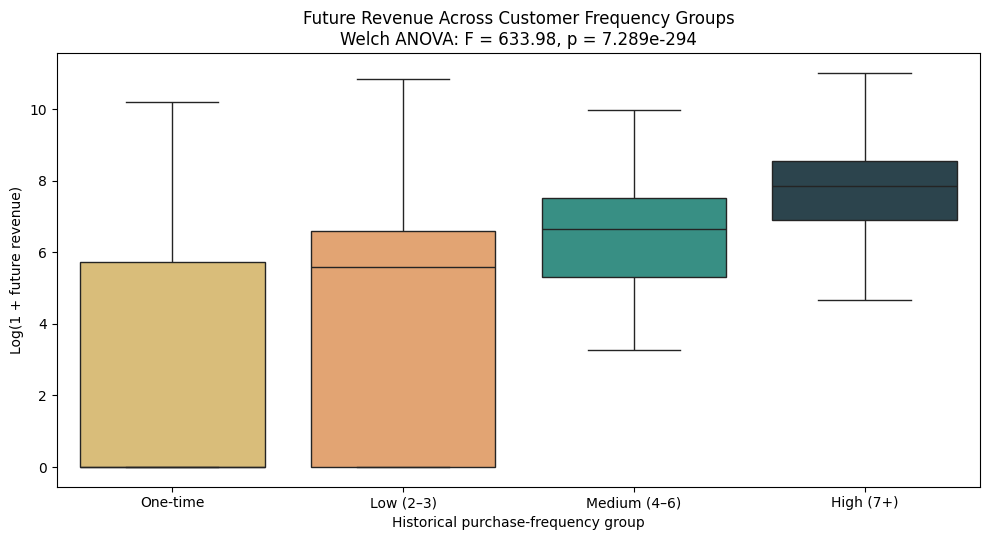

In [ ]:
plt.figure(figsize=(10, 5.5))

sns.boxplot(
    data=customer_data,
    x="FrequencyGroup",
    y="LogFutureRevenue",
    order=group_order,
    palette=["#E9C46A", "#F4A261", "#2A9D8F", "#264653"],
    showfliers=False
)

plt.xlabel("Historical purchase-frequency group")
plt.ylabel("Log(1 + future revenue)")
plt.title(
    f"Future Revenue Across Customer Frequency Groups\n"
    f"Welch ANOVA: F = {welch_f:.2f}, p = {welch_p:.4g}"
)

plt.tight_layout()
plt.savefig(
    "future_revenue_frequency_groups.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from statsmodels.stats.oneway import effectsize_oneway

group_means = welch_anova.means
group_variances = welch_anova.vars_
group_sizes = welch_anova.nobs

welch_f_squared = effectsize_oneway(
    group_means,
    group_variances,
    group_sizes,
    use_var="unequal"
)

welch_eta_squared = (
    welch_f_squared / (1 + welch_f_squared)
)

print(f"Welch f-squared: {welch_f_squared:.4f}")
print(f"Approximate eta-squared: {welch_eta_squared:.4f}")

Welch f-squared: 0.4461
Approximate eta-squared: 0.3085


### Welch’s ANOVA Results and Interpretation

Welch’s one-way analysis of variance was conducted to determine whether mean future revenue differed across four customer groups defined by their historical purchase frequency:

1. One-time customers: 1 purchase
2. Low-frequency customers: 2–3 purchases
3. Medium-frequency customers: 4–6 purchases
4. High-frequency customers: 7 or more purchases

Future revenue was transformed using:

$$
Y=\log(1+\text{Future Revenue})
$$

The logarithmic transformation was used because future revenue was strongly right-skewed and included customers with zero future revenue. Adding one allows the logarithm to be calculated for these zero values.

The statistical hypotheses were:

$$
H_0:\mu_{\text{One-time}}
=\mu_{\text{Low}}
=\mu_{\text{Medium}}
=\mu_{\text{High}}
$$

$$
H_1:\text{At least one population mean is different}
$$

Welch’s ANOVA was selected because it does not require equal population variances or equal group sizes. This was appropriate because the four frequency groups contained different numbers of customers and displayed different variances.

The test produced the following result:

$$
F_W(3,2113.21)=633.98,\quad p<0.001
$$

The p-value was substantially below the 5% significance level. Therefore, the null hypothesis was rejected. There is statistically significant evidence that mean log future revenue differs across the four historical purchase-frequency groups.

The observed mean log future revenues were:

* One-time customers: 2.37
* Low-frequency customers: 4.10
* Medium-frequency customers: 5.64
* High-frequency customers: 7.38

A clear increasing pattern can be observed:

$$
\text{One-time}<\text{Low}<\text{Medium}<\text{High}
$$

This suggests that customers who purchased more frequently during the historical observation period generally generated more revenue during the future period.

### Post-hoc Pairwise Comparisons

A statistically significant ANOVA result only indicates that at least one group mean differs. Therefore, pairwise Welch t-tests were performed to determine which particular groups differed. The Holm correction was applied to control the family-wise Type I error rate created by conducting multiple comparisons.

All six pairwise comparisons were statistically significant after the Holm adjustment, with adjusted \(p<0.001\). Significant differences were identified between:

* One-time and low-frequency customers
* One-time and medium-frequency customers
* One-time and high-frequency customers
* Low-frequency and medium-frequency customers
* Low-frequency and high-frequency customers
* Medium-frequency and high-frequency customers

The negative mean differences shown in the table occurred because the mean of the first group was subtracted from the mean of the second group. For example:

$$
2.3720-7.3799=-5.0079
$$

Therefore, the negative value indicates that high-frequency customers had higher mean log future revenue than one-time customers. It does not indicate an error in the analysis.

### Business Interpretation

The descriptive statistics demonstrate that the statistical differences are also practically meaningful. The average future revenue increased from 304.97 among one-time customers to 6,370.83 among high-frequency customers. The repeat-purchase rate also increased from 38.78% to 93.05%.

The median future revenue of one-time customers was zero, indicating that more than half of these customers generated no revenue during the future period. In comparison, high-frequency customers had a median future revenue of 2,603.43.

These findings indicate that historical purchase frequency is a strong indicator of future customer value. High-frequency customers should therefore be considered an important group for retention and loyalty strategies. However, because this analysis uses observational transaction data, the result demonstrates association rather than proving that purchase frequency directly causes higher future revenue.
